In [ ]:
import os, shutil, pathlib
original_dir = pathlib.Path("C:/Users/whylo/Desktop/MITA_Second_Year/NNDL/hw/hw3/train")
new_base_dir = pathlib.Path("C:/Users/whylo/Desktop/MITA_Second_Year/NNDL/hw/hw3/cats_vs_dogs_small")
def make_subset(subset_name, start_index, end_index):
    for category in ("cat", "dog"):
        dir = new_base_dir / subset_name / category
        os.makedirs(dir)
        fnames = [f"{category}.{i}.jpg" for i in range(start_index, end_index)]
        for fname in fnames:
            shutil.copyfile(src=original_dir / fname,dst=dir / fname)
make_subset("train", start_index=0, end_index=1000)
make_subset("validation", start_index=1000, end_index=1500)
make_subset("test", start_index=1500, end_index=2500)


In [7]:
from tensorflow import keras
from tensorflow.keras import layers
inputs = keras.Input(shape=(180, 180, 3))
x = layers.experimental.preprocessing.Rescaling(1./255)(inputs)
x = layers.Conv2D(filters=32, kernel_size=3, activation="relu")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=64, kernel_size=3, activation="relu")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=128, kernel_size=3, activation="relu")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=256, kernel_size=3, activation="relu")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=256, kernel_size=3, activation="relu")(x)
x = layers.Flatten()(x)
outputs = layers.Dense(1, activation="sigmoid")(x)
model = keras.model2222222(inputs=inputs, outputs=outputs)
model.compile(loss="binary_crossentropy",optimizer="rmsprop",metrics=["accuracy"])

In [8]:
from tensorflow.keras.preprocessing import image_dataset_from_directory
train_dataset = image_dataset_from_directory(new_base_dir / "train",image_size=(180, 180),batch_size=32)
validation_dataset = image_dataset_from_directory(new_base_dir / "validation",image_size=(180, 180),batch_size=32)
test_dataset = image_dataset_from_directory(new_base_dir / "test",image_size=(180, 180),batch_size=32)


Found 2000 files belonging to 2 classes.
Found 1000 files belonging to 2 classes.
Found 2000 files belonging to 2 classes.


In [50]:
make_subset("visual", start_index=255, end_index=256)
visual_dataset = image_dataset_from_directory(new_base_dir / "visual",image_size=(180, 180),batch_size=32)

Found 2 files belonging to 2 classes.


<BatchDataset element_spec=(TensorSpec(shape=(None, 180, 180, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>

In [9]:
callbacks = [keras.callbacks.model22Checkpoint(filepath="convnet_from_scratch.keras",save_best_only=True,monitor="val_loss")]
history = model.fit(train_dataset,epochs=30,validation_data=validation_dataset,callbacks=callbacks)

Epoch 1/30
63/63 [==============================] - 10s 93ms/step - loss: 0.7657 - accuracy: 0.5330 - val_loss: 0.6906 - val_accuracy: 0.5580
Epoch 2/30
63/63 [==============================] - 5s 72ms/step - loss: 0.7027 - accuracy: 0.5515 - val_loss: 0.6795 - val_accuracy: 0.5770
Epoch 3/30
63/63 [==============================] - 5s 72ms/step - loss: 0.6589 - accuracy: 0.6495 - val_loss: 0.6390 - val_accuracy: 0.6220
Epoch 4/30
63/63 [==============================] - 5s 71ms/step - loss: 0.6172 - accuracy: 0.6760 - val_loss: 0.6198 - val_accuracy: 0.6510
Epoch 5/30
63/63 [==============================] - 5s 71ms/step - loss: 0.5860 - accuracy: 0.7075 - val_loss: 0.6134 - val_accuracy: 0.6690
Epoch 6/30
63/63 [==============================] - 5s 71ms/step - loss: 0.5468 - accuracy: 0.7430 - val_loss: 0.6761 - val_accuracy: 0.6920
Epoch 7/30
63/63 [==============================] - 5s 72ms/step - loss: 0.4990 - accuracy: 0.7595 - val_loss: 0.5894 - val_accuracy: 0.7060
Epoch 8/30
6

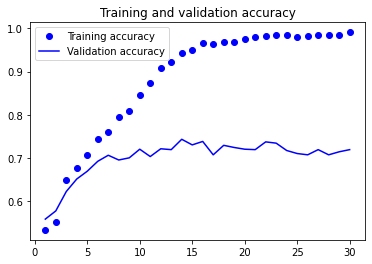

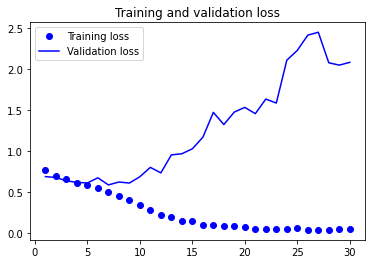

In [10]:
import matplotlib.pyplot as plt
accuracy = history.history["accuracy"]
val_accuracy = history.history["val_accuracy"]
loss = history.history["loss"]
val_loss = history.history["val_loss"]
epochs = range(1, len(accuracy) + 1)
plt.plot(epochs, accuracy, "bo", label="Training accuracy")
plt.plot(epochs, val_accuracy, "b", label="Validation accuracy")
plt.title("Training and validation accuracy")
plt.legend()
plt.figure()
plt.plot(epochs, loss, "bo", label="Training loss")
plt.plot(epochs, val_loss, "b", label="Validation loss")
plt.title("Training and validation loss")
plt.legend()
plt.show()

In [11]:
test_model = keras.models.load_model("convnet_from_scratch.keras")
test_loss, test_acc = test_model.evaluate(test_dataset)
print(f"Test accuracy: {test_acc:.3f}")

63/63 [==============================] - 2s 26ms/step - loss: 0.6053 - accuracy: 0.7125
Test accuracy: 0.712


In [12]:
data_augmentation = keras.Sequential(
    [
        layers.experimental.preprocessing.RandomFlip("horizontal"),
        layers.experimental.preprocessing.RandomRotation(0.1),
        layers.experimental.preprocessing.RandomZoom(0.2),
    ]
)


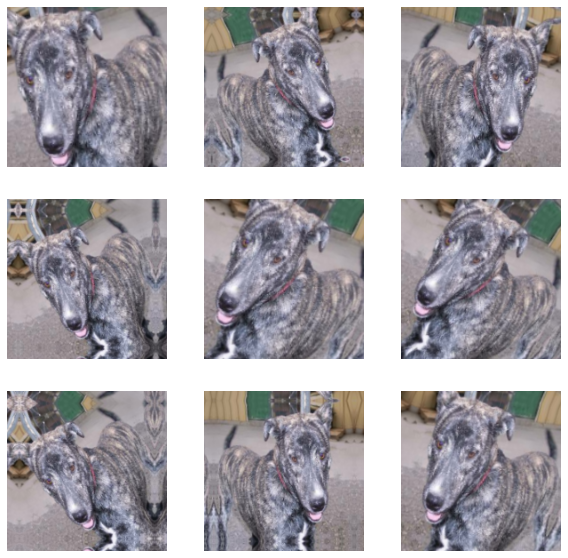

In [14]:
plt.figure(figsize=(10, 10))
for images, _ in train_dataset.take(1):
    for i in range(9):
        augmented_images = data_augmentation(images)
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(augmented_images[0].numpy().astype("uint8"))
        plt.axis("off")

In [23]:
inputs = keras.Input(shape=(180, 180, 3))
x = data_augmentation(inputs)
x = layers.experimental.preprocessing.Rescaling(1./255)(x)
x = layers.Conv2D(filters=32, kernel_size=3, activation="relu")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=64, kernel_size=3, activation="relu")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=128, kernel_size=3, activation="relu")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=256, kernel_size=3, activation="relu")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=256, kernel_size=3, activation="relu")(x)
x = layers.Flatten()(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(1, activation="sigmoid")(x)
model = keras.Model(inputs=inputs, outputs=outputs)
model.compile(loss="binary_crossentropy",optimizer="rmsprop",metrics=["accuracy"])

In [24]:
callbacks = [
    keras.callbacks.ModelCheckpoint(
    filepath="convnet_from_scratch_with_augmentation.keras",
    save_best_only=True,
    monitor="val_loss")
]
history = model.fit(
    train_dataset,
    epochs=100,
    validation_data=validation_dataset,
    callbacks=callbacks)

Epoch 1/100
63/63 [==============================] - 6s 78ms/step - loss: 0.7297 - accuracy: 0.5230 - val_loss: 0.8203 - val_accuracy: 0.5000
Epoch 2/100
63/63 [==============================] - 4s 69ms/step - loss: 0.6939 - accuracy: 0.5680 - val_loss: 0.6778 - val_accuracy: 0.5660
Epoch 3/100
63/63 [==============================] - 4s 69ms/step - loss: 0.6853 - accuracy: 0.5910 - val_loss: 0.6312 - val_accuracy: 0.6280
Epoch 4/100
63/63 [==============================] - 4s 69ms/step - loss: 0.6338 - accuracy: 0.6405 - val_loss: 0.6494 - val_accuracy: 0.6090
Epoch 5/100
63/63 [==============================] - 4s 68ms/step - loss: 0.6208 - accuracy: 0.6535 - val_loss: 0.6357 - val_accuracy: 0.6250
Epoch 6/100
63/63 [==============================] - 4s 68ms/step - loss: 0.6028 - accuracy: 0.6805 - val_loss: 0.6718 - val_accuracy: 0.6040
Epoch 7/100
63/63 [==============================] - 4s 69ms/step - loss: 0.5990 - accuracy: 0.6720 - val_loss: 0.6145 - val_accuracy: 0.6730
Epoch 

In [17]:
test_model = keras.models.load_model("convnet_from_scratch_with_augmentation.keras")
test_loss, test_acc = test_model.evaluate(test_dataset)
print(f"Test accuracy: {test_acc:.3f}")

63/63 [==============================] - 2s 25ms/step - loss: 0.4963 - accuracy: 0.8245
Test accuracy: 0.825


Model: "model_31"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_6 (InputLayer)        [(None, 180, 180, 3)]     0         
                                                                 
 sequential (Sequential)     (None, 180, 180, 3)       0         
                                                                 
 rescaling_2 (Rescaling)     (None, 180, 180, 3)       0         
                                                                 
 conv2d_10 (Conv2D)          (None, 178, 178, 32)      896       
                                                                 
Total params: 896
Trainable params: 896
Non-trainable params: 0
_________________________________________________________________


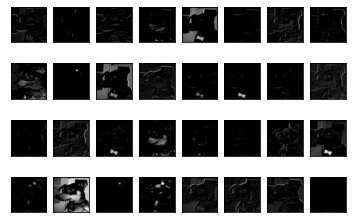

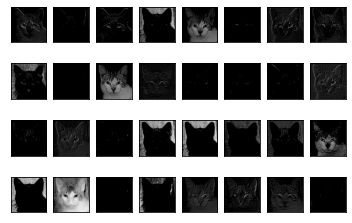

In [68]:
# plot feature map of first conv layer for given image

from keras.preprocessing.image import load_img
from keras.preprocessing.image import img_to_array
from keras.models import Model
from matplotlib import pyplot
from numpy import expand_dims
# load the model

# redefine model to output right after the first hidden layer
model2 = Model(inputs=model.inputs, outputs=model.layers[3].output)
model2.summary()
# load the image with the required shape
# get feature map for first hidden layer
feature_maps = model2.predict(visual_dataset)

# plot all 64 maps in an 8x8 squares
square1 = 4
square2 = 8
ix = 1
for _ in range(square1):
	for _ in range(square2):
		# specify subplot and turn of axis
		ax = pyplot.subplot(square1, square2, ix)
		ax.set_xticks([])
		ax.set_yticks([])
		# plot filter channel in grayscale
		pyplot.imshow(feature_maps[0, :, :, ix-1], cmap='gray')
		ix += 1
pyplot.show()
ix = 1
for _ in range(square1):
	for _ in range(square2):
		# specify subplot and turn of axis
		ax = pyplot.subplot(square1, square2, ix)
		ax.set_xticks([])
		ax.set_yticks([])
		# plot filter channel in grayscale
		pyplot.imshow(feature_maps[1, :, :, ix-1], cmap='gray')
		ix += 1
pyplot.show()

---
VGG16
---


In [18]:
conv_base = keras.applications.vgg16.VGG16(
    weights="imagenet",
    include_top=False,
    input_shape=(180, 180, 3))

58900480/58889256 [==============================] - 1s 0us/step


In [19]:
import numpy as np
def get_features_and_labels(dataset):
    all_features = []
    all_labels = []
    for images, labels in dataset:
        preprocessed_images = keras.applications.vgg16.preprocess_input(images)
        features = conv_base.predict(preprocessed_images)
        all_features.append(features)
        all_labels.append(labels)
    return np.concatenate(all_features), np.concatenate(all_labels)
train_features, train_labels = get_features_and_labels(train_dataset)
val_features, val_labels = get_features_and_labels(validation_dataset)
test_features, test_labels = get_features_and_labels(test_dataset)

In [20]:
inputs = keras.Input(shape=(5, 5, 512))
x = layers.Flatten()(inputs)
x = layers.Dense(256)(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(1, activation="sigmoid")(x)
model = keras.Model(inputs, outputs)
model.compile(loss="binary_crossentropy",
    optimizer="rmsprop",
    metrics=["accuracy"])
callbacks = [
    keras.callbacks.ModelCheckpoint(
    filepath="feature_extraction.keras",
    save_best_only=True,
    monitor="val_loss")
]
history = model.fit(
    train_features, train_labels,
    epochs=20,
    validation_data=(val_features, val_labels),
    callbacks=callbacks)

Epoch 1/20
63/63 [==============================] - 1s 8ms/step - loss: 18.8435 - accuracy: 0.9250 - val_loss: 5.1013 - val_accuracy: 0.9620
Epoch 2/20
63/63 [==============================] - 0s 6ms/step - loss: 3.9639 - accuracy: 0.9785 - val_loss: 5.0028 - val_accuracy: 0.9740
Epoch 3/20
63/63 [==============================] - 0s 6ms/step - loss: 1.8794 - accuracy: 0.9865 - val_loss: 5.4350 - val_accuracy: 0.9720
Epoch 4/20
63/63 [==============================] - 0s 6ms/step - loss: 1.9144 - accuracy: 0.9870 - val_loss: 8.1598 - val_accuracy: 0.9620
Epoch 5/20
63/63 [==============================] - 0s 7ms/step - loss: 1.5791 - accuracy: 0.9865 - val_loss: 4.3382 - val_accuracy: 0.9750
Epoch 6/20
63/63 [==============================] - 0s 6ms/step - loss: 0.8383 - accuracy: 0.9940 - val_loss: 5.1743 - val_accuracy: 0.9760
Epoch 7/20
63/63 [==============================] - 0s 6ms/step - loss: 0.6919 - accuracy: 0.9960 - val_loss: 5.2969 - val_accuracy: 0.9800
Epoch 8/20
63/63 [=

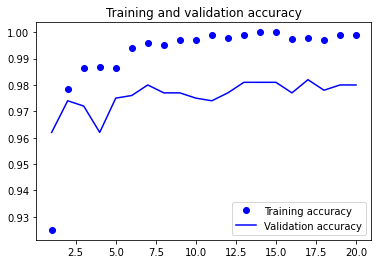

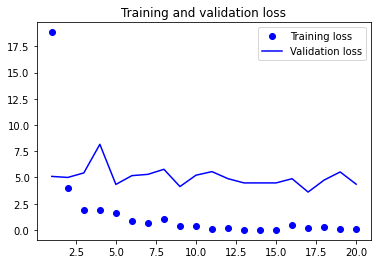

In [21]:
import matplotlib.pyplot as plt
acc = history.history["accuracy"]
val_acc = history.history["val_accuracy"]
loss = history.history["loss"]
val_loss = history.history["val_loss"]
epochs = range(1, len(acc) + 1)
plt.plot(epochs, acc, "bo", label="Training accuracy")
plt.plot(epochs, val_acc, "b", label="Validation accuracy")
plt.title("Training and validation accuracy")
plt.legend()
plt.figure()
plt.plot(epochs, loss, "bo", label="Training loss")
plt.plot(epochs, val_loss, "b", label="Validation loss")
plt.title("Training and validation loss")
plt.legend()
plt.show()